# **ARTIFICIAL INTELLIGENCE CAPSTONE PROJECT – PRAICP-1000 : Indian Sign Language (ISL) Recognition**

**PROJECT TITLE:** PRAICP-1000: IndiSignLang – Indian Sign Language Recognition

**TEAM CODE:**  PTID-AIE-JUL-26-11142

**PROJECT CODE:** PRAICP-1000

**PROJECT TYPE:** Artificial Intelligence Capstone Project

**DATASET SOURCE:** DataMites Capstone Project Dataset

**DATASET NAME:** IndiSignLang (directories of sign images, one directory per sign)

**DATASET LINK:** https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1000-IndiSignLang.zip

**SUBMITTED BY:** Sameeksha

## **1. Problem Statement & Project Objective**

**1.  Problem Statement**

Sign language is the primary medium of communication for many people who are deaf or hard of hearing, but most people do not understand it, which creates a communication barrier in education, healthcare, public services and everyday life. The objective of this project is to develop a Convolutional Neural Network (CNN) based machine learning model that can look at a photograph of a hand sign from the Indian Sign Language (ISL) dataset and automatically predict which sign it represents, improving communication accessibility.

**2. Project Objective**

The DataMites project brief defines two goals, both of which are covered in this notebook:

1. **Image preprocessing** – convert raw, variable-resolution sign photographs into a clean, consistent numerical format (resize, normalise, augment) that a neural network can learn from.
2. **ML model to predict the sign** – build, tune and evaluate a CNN that classifies each image into its sign class.

To achieve this, the notebook will:

1. Load and explore the dataset (classes, class balance, image sizes, sample images).
2. Preprocess the images (resize to a fixed size, normalise pixel values) and split them into Training / Validation / Test sets.
3. Apply data augmentation (small rotations, shifts and zooms) to improve generalisation.
4. Build a baseline CNN , then improve it with hyperparameter tuning (Keras Tuner) to obtain a final CNN.
5. Evaluate the models with Accuracy, Precision, Recall, F1-score, a Confusion Matrix and a Classification Report.
6. Predict the sign for a brand-new image and save the trained model.

## **2. Import Python Libraries**

The required Python libraries are imported to perform dataset downloading, image loading and preprocessing, visualisation, CNN model development, hyperparameter tuning and performance evaluation. TensorFlow/Keras is used to build and train the CNN models, Keras Tuner is used to search for the best hyperparameters, and Scikit-learn provides the data-splitting utilities and evaluation metrics.

In [1]:
# Keras Tuner (hyperparameter tuning) and tqdm (progress bars) - needed on Google Colab; harmless if already installed
!pip install -q keras-tuner tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.1 MB/s eta 0:00:00


In [2]:
# Core Libraries
import os
import json
import gc
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# Downloading the dataset
import requests

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                     RandomRotation, RandomTranslation, RandomZoom)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Hyperparameter tuning
import keras_tuner as kt

# Reproducibility: fix the random seeds so results are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')

print('TensorFlow version :', tf.__version__)
print('Keras Tuner version:', kt.__version__)
print('GPU available      :', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version : 2.20.0
Keras Tuner version: 1.4.8
GPU available      : False


## **3. Upload the Dataset And Domain Analysis**

**1. Upload the Dataset**

The dataset is provided by DataMites as a ZIP file. It contains one directory per sign, and each directory holds the photographs of that sign. The directory name is therefore the label (class) of every image inside it. The code below downloads and extracts the ZIP (each step is skipped automatically if it has already been done) and then automatically detects the folder that contains the class directories, so it works even if the ZIP is laid out slightly differently.

**2. Domain Analysis**

Each image in this dataset shows a single hand, photographed against a plain background, forming one static sign. The meaning of a sign is carried almost entirely by the shape of the hand – which fingers are extended, curled or crossed, how the thumb is placed and how the palm is oriented. Because these are spatial visual patterns, this is a natural candidate for a CNN, which learns edge, shape and finger-configuration features directly from pixels instead of relying on hand-crafted features.

Only static signs can be recognised from a single photograph. Signs that need hand *movement* cannot be captured in one still image – this is why the letters **J** and **Z**, which are commonly signed with a motion, are not expected in the class list. Note that different signs can look very similar (for example closed-fist shapes that differ only in thumb position), which makes some classes harder to separate than others.

In [3]:
# Download and extract the dataset (each step is skipped automatically if already done)
DATASET_URL = 'https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1000-IndiSignLang.zip'
ZIP_PATH    = 'PRAICP-1000-IndiSignLang.zip'
EXTRACT_DIR = 'IndiSignLang_data'

def download_file(url, dest_path, chunk_size=1 << 20):
    """Stream-download a file with a simple progress printout."""
    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        downloaded = 0
        with open(dest_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        print(f'\rDownloading... {downloaded/1e6:,.1f} MB / {total/1e6:,.1f} MB '
                              f'({downloaded/total*100:.0f}%)', end='')
    print('\nDownload complete.')

if not os.path.exists(ZIP_PATH):
    download_file(DATASET_URL, ZIP_PATH)
else:
    print('ZIP file already present, skipping download.')

if not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('Extraction complete.')
else:
    print('Dataset already extracted, skipping extraction.')

Downloading... 84.6 MB / 84.6 MB (100%)
Download complete.
Extraction complete.


In [4]:
# Auto-detect the folder that directly contains the class (sign) directories
IMG_EXT = ('.jpg', '.jpeg', '.png')

def find_dataset_root(base):
    """Return the directory whose sub-folders contain the most image-holding class folders."""
    best_dir, best_n = None, 0
    for dirpath, dirnames, _ in os.walk(base):
        dirnames[:] = [d for d in dirnames if not d.startswith(('__', '.'))]   # ignore __MACOSX etc.
        n = sum(1 for d in dirnames
                if any(f.lower().endswith(IMG_EXT) for f in os.listdir(os.path.join(dirpath, d))))
        if n > best_n:
            best_dir, best_n = dirpath, n
    return best_dir

DATASET_PATH = find_dataset_root(EXTRACT_DIR)
CLASS_NAMES = sorted(d for d in os.listdir(DATASET_PATH)
                     if os.path.isdir(os.path.join(DATASET_PATH, d)))
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

print('Dataset folder  :', DATASET_PATH)
print('Number of classes:', NUM_CLASSES)
print('Classes          :', CLASS_NAMES)

Dataset folder  : IndiSignLang_data/Data
Number of classes: 24
Classes          : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


## **4. Basic Checks**

Basic checks are performed to understand the size, quality and balance of the dataset before exploratory analysis and model development. A table with one row per image is created (its class, file path, width, height and colour mode), every file is opened to make sure it is **not corrupt**, and the number of images per class is counted to see whether the dataset is balanced.

In [5]:
# Build a table with one row per image
records = []
for cls in CLASS_NAMES:
    folder = os.path.join(DATASET_PATH, cls)
    for fname in sorted(os.listdir(folder)):
        if fname.lower().endswith(IMG_EXT):
            records.append({'class': cls, 'file': fname, 'path': os.path.join(folder, fname)})

df = pd.DataFrame(records)
print('Total number of images found:', len(df))
df.head()

Total number of images found: 4972


,class,file,path
0,A,001.jpg,IndiSignLang_data/Data/A/001.jpg
1,A,002.jpg,IndiSignLang_data/Data/A/002.jpg
2,A,003.jpg,IndiSignLang_data/Data/A/003.jpg
3,A,004.jpg,IndiSignLang_data/Data/A/004.jpg
4,A,005.jpg,IndiSignLang_data/Data/A/005.jpg


In [6]:
# Check every image: is it readable (not corrupt)? What are its width, height and colour mode?
widths, heights, modes, corrupt_files = [], [], [], []

for p in tqdm(df['path'], desc='Checking images'):
    try:
        with Image.open(p) as img:
            w, h = img.size
            mode = img.mode
            img.verify()                  # raises an exception for corrupt / truncated files
        widths.append(w); heights.append(h); modes.append(mode)
    except Exception:
        widths.append(None); heights.append(None); modes.append(None)
        corrupt_files.append(p)

df['width'], df['height'], df['mode'] = widths, heights, modes

print('Number of corrupt/unreadable images found:', len(corrupt_files))
if corrupt_files:
    print(corrupt_files[:10])
    df = df[~df['path'].isin(corrupt_files)].reset_index(drop=True)    # drop them so they cannot break training
    print('Corrupt files removed. Remaining images:', len(df))

Checking images:   0%|          | 0/4972 [00:00<?, ?it/s]

Number of corrupt/unreadable images found: 0


In [7]:
# Images per class and overall class balance
class_counts = df['class'].value_counts().reindex(CLASS_NAMES)
print(class_counts.to_string())
print()
print('Total images          :', len(df))
print('Smallest class        :', class_counts.idxmin(), '->', class_counts.min(), 'images')
print('Largest class         :', class_counts.idxmax(), '->', class_counts.max(), 'images')
print('Imbalance ratio (max/min): {:.2f} : 1'.format(class_counts.max() / class_counts.min()))
print('File formats          :', sorted(set(os.path.splitext(f)[1].lower() for f in df['file'])))
print('Colour modes          :', df['mode'].value_counts().to_dict())

class
A    242
B    259
C    247
D    147
E    243
F    226
G    241
H    116
I    179
K    245
L    182
M    235
N    237
O    229
P    234
Q    216
R    211
S    229
T    216
U    135
V    122
W    128
X    202
Y    251

Total images          : 4972
Smallest class        : H -> 116 images
Largest class         : B -> 259 images
Imbalance ratio (max/min): 2.23 : 1
File formats          : ['.jpg']
Colour modes          : {'RGB': 4972}


In [8]:
# Image resolutions present in the dataset
size_table = (df.groupby(['width', 'height']).size()
                .reset_index(name='Number of images')
                .sort_values('Number of images', ascending=False))
size_table['Orientation'] = np.where(size_table['width'] > size_table['height'], 'Landscape', 'Portrait')
size_table

,width,height,Number of images,Orientation
0,640,480,3963,Landscape
2,1920,1088,830,Landscape
1,1088,1920,179,Portrait


## **5. Exploratory Data Analysis (EDA) — Data Analysis Report**

Exploratory Data Analysis is performed to visually understand the dataset before building the CNN. This includes the class distribution, the resolutions of the original images, one sample image from every sign, and several samples from a single sign to see how much variation exists *within* a class (different hands, angles, lighting and sharpness).

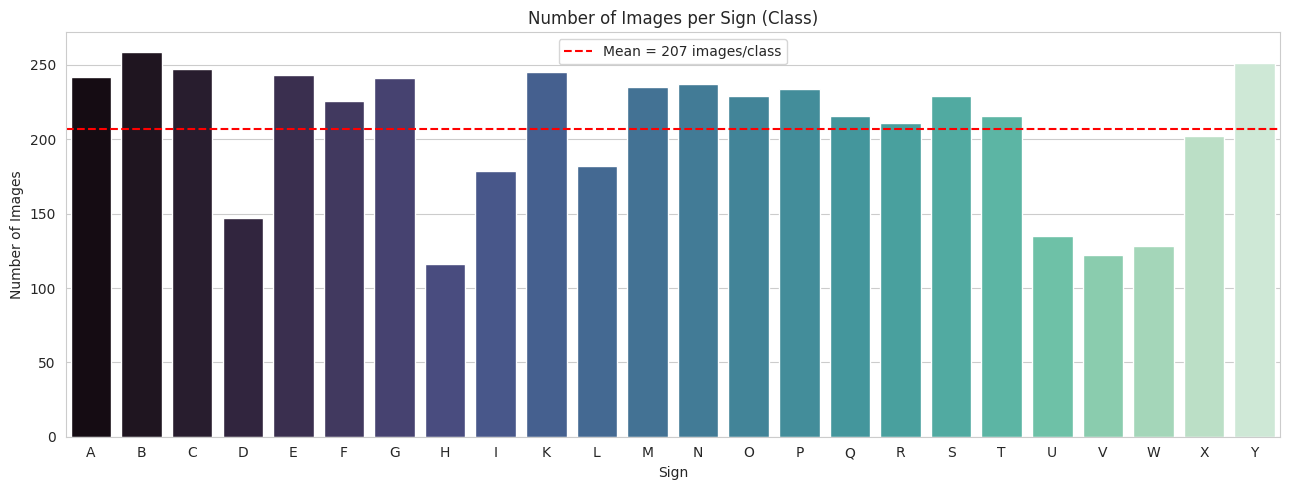

In [9]:
# Class distribution
plt.figure(figsize=(13, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='mako')
plt.axhline(class_counts.mean(), color='red', linestyle='--', label=f'Mean = {class_counts.mean():.0f} images/class')
plt.title('Number of Images per Sign (Class)')
plt.xlabel('Sign')
plt.ylabel('Number of Images')
plt.legend()
plt.tight_layout()
plt.show()

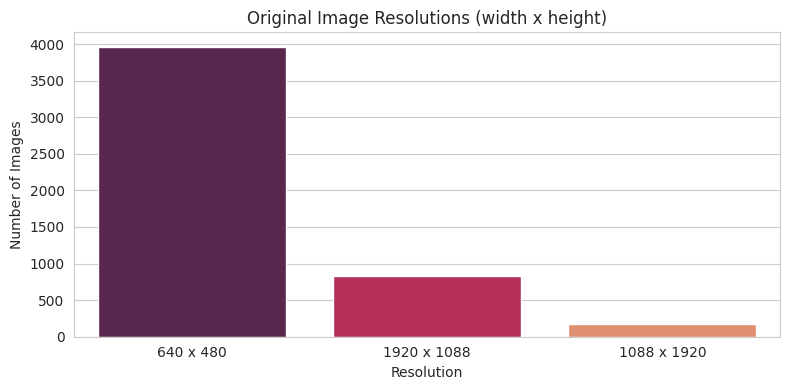

In [10]:
# Distribution of the original image resolutions
size_label = df['width'].astype(int).astype(str) + ' x ' + df['height'].astype(int).astype(str)
plt.figure(figsize=(8, 4))
sns.countplot(x=size_label, order=size_label.value_counts().index, palette='rocket')
plt.title('Original Image Resolutions (width x height)')
plt.xlabel('Resolution')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

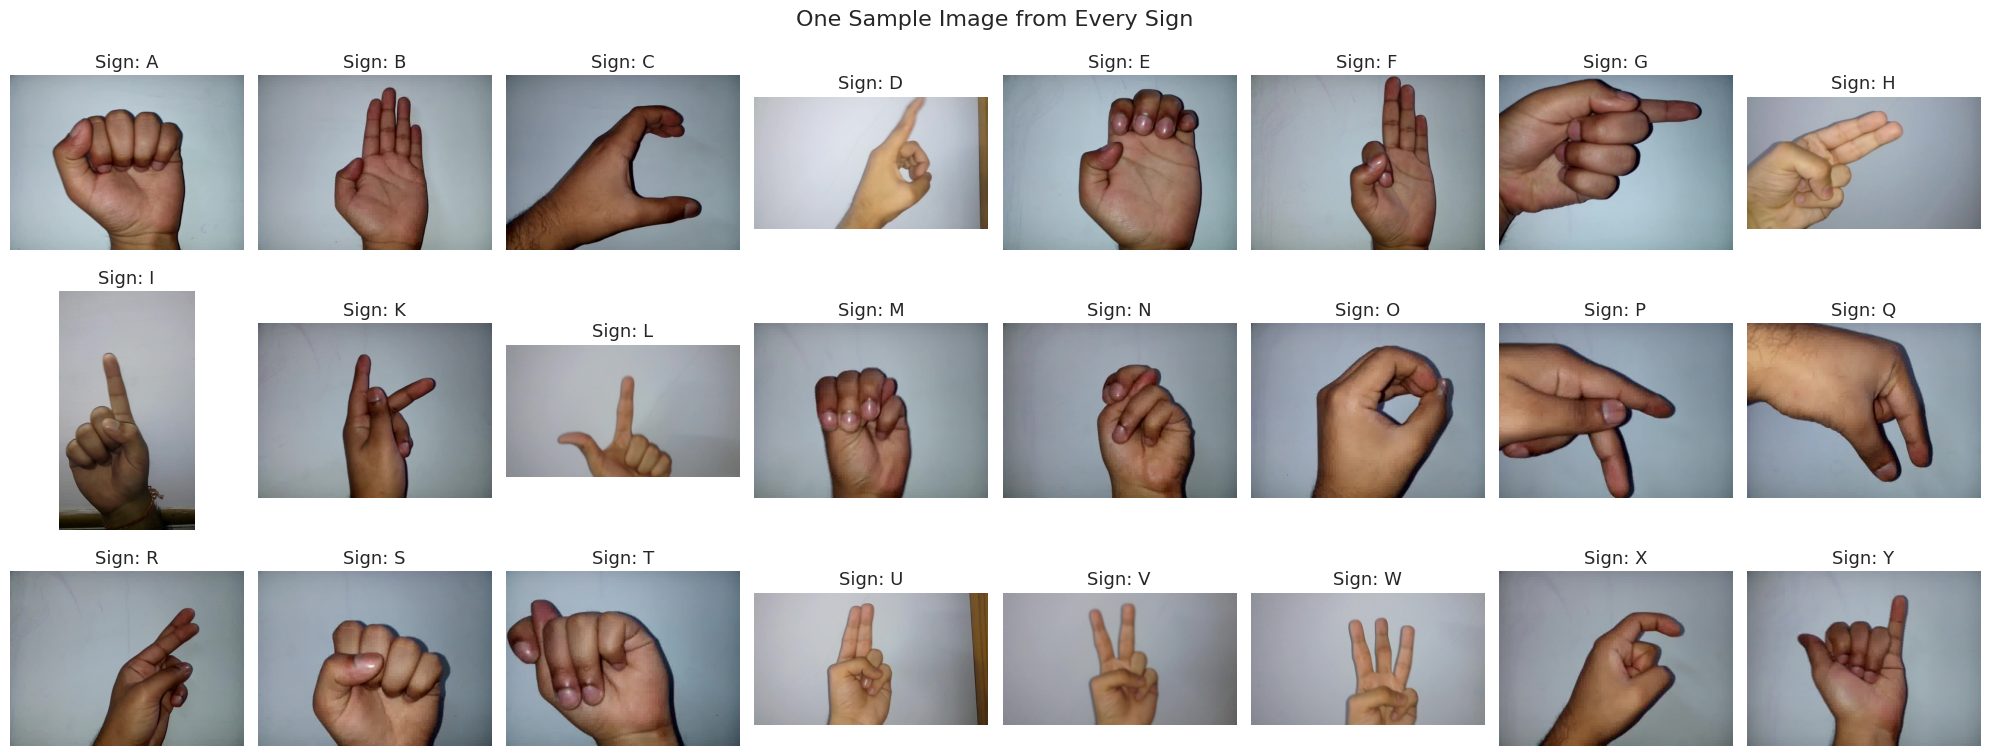

In [11]:
# One sample image from every sign
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
for ax, cls in zip(axes.ravel(), CLASS_NAMES):
    sample_path = df[df['class'] == cls].sample(1, random_state=SEED)['path'].values[0]
    ax.imshow(Image.open(sample_path))
    ax.set_title(f'Sign: {cls}', fontsize=13)
    ax.axis('off')
for ax in axes.ravel()[NUM_CLASSES:]:
    ax.axis('off')
plt.suptitle('One Sample Image from Every Sign', fontsize=16)
plt.tight_layout()
plt.show()

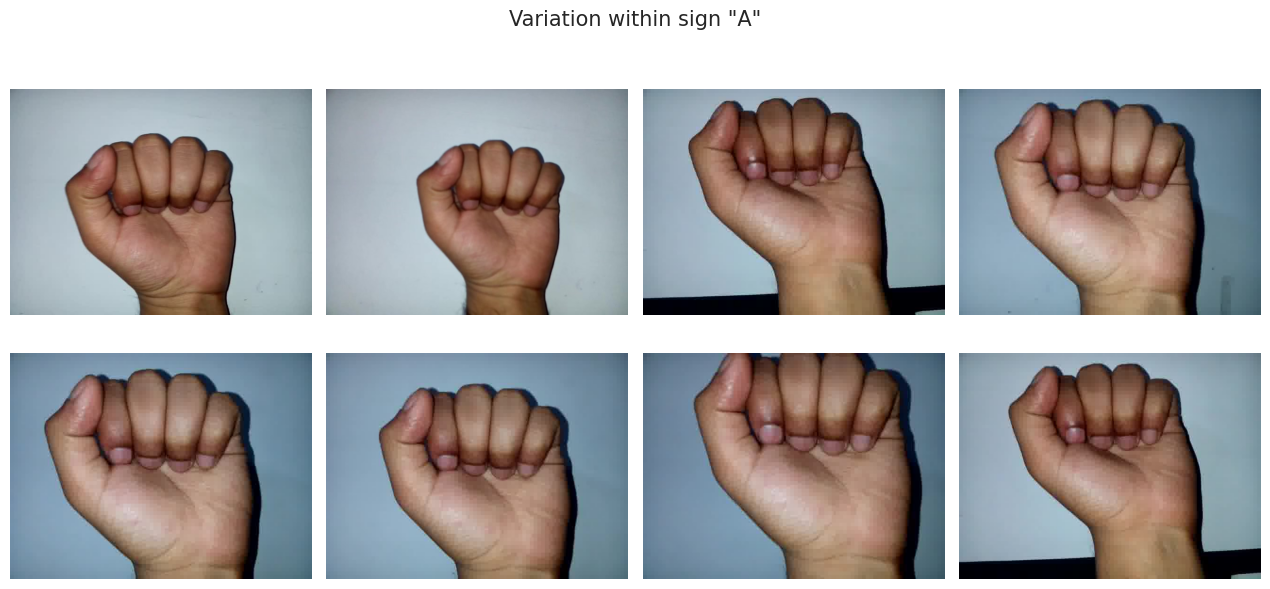

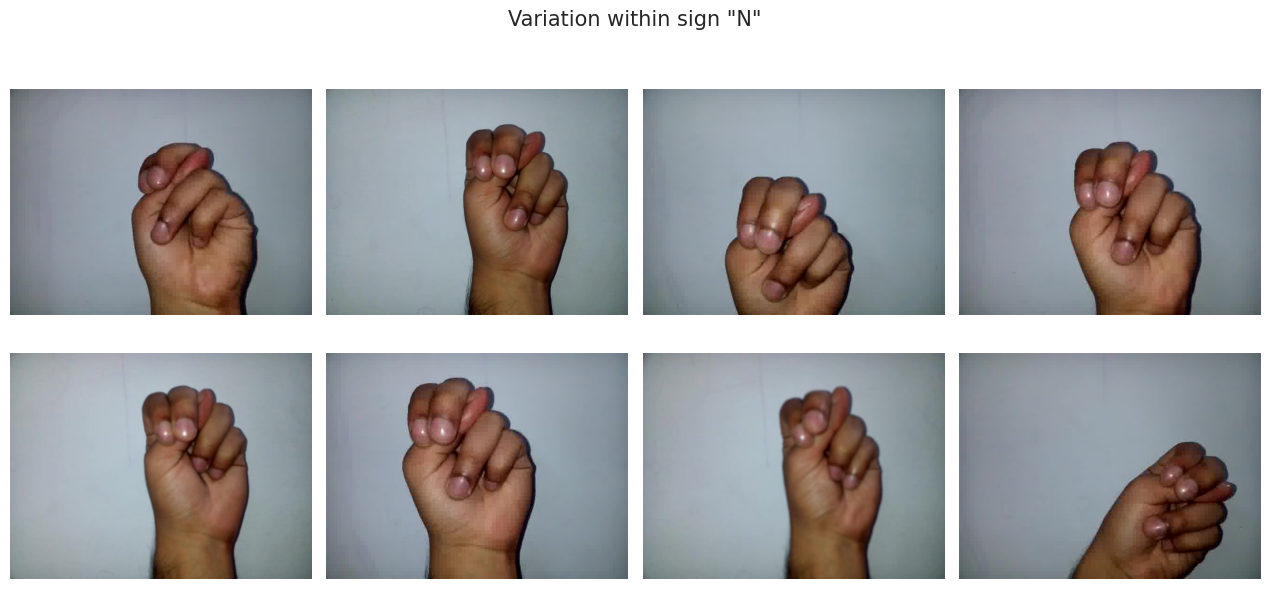

In [12]:
# Variation WITHIN a class: 8 random images of the same sign
def show_class_variation(cls, n=8):
    files = df[df['class'] == cls].sample(n, random_state=SEED)['path'].values
    fig, axes = plt.subplots(2, n // 2, figsize=(3.2 * (n // 2), 6.4))
    for ax, p in zip(axes.ravel(), files):
        ax.imshow(Image.open(p))
        ax.axis('off')
    plt.suptitle(f'Variation within sign "{cls}"', fontsize=15)
    plt.tight_layout()
    plt.show()

show_class_variation(CLASS_NAMES[0])
show_class_variation(CLASS_NAMES[len(CLASS_NAMES) // 2])

###**EDA Summary (Conclusion):**

1.The dataset contains **24 sign classes** (the letters A–Y without J and Z, which are not present) and **4,972 images**, all stored as RGB JPEG files. No corrupt or unreadable files were found in the corrupt-file check.

2.The classes are **moderately imbalanced**: the smallest class (H) has 116 images while the largest (B) has 259, an imbalance ratio of roughly 2.2 : 1. This is not extreme, but it is addressed later by using **stratified splitting** (so every split keeps the same class proportions) and **class weights** during training.

3.The images come in **three different resolutions** – 640 × 480 (3,963 images), 1920 × 1088 (830 images) and 1088 × 1920 portrait (179 images). A CNN needs a fixed input size, which confirms the need for the resizing step in the preprocessing section.

4.The sample images show a single hand on a plain, light background, which is helpful because the background carries little confusing information. However, images within the same class vary in hand size, skin tone, camera angle, position in the frame and sharpness (some are motion-blurred), which supports the use of **data augmentation** to help the model generalise.

5.Some signs are visually very close to each other (for example signs formed with a closed fist or curled fingers). These are expected to be the hardest to separate and will be examined later in the confusion matrix.

## **6. Image Preprocessing**

Image preprocessing is the first of the two goals in the project brief. A CNN cannot accept images of different sizes and learns best when its inputs are on a small, consistent numerical scale. Two preprocessing steps are therefore applied to **every** image:

**1. Resize** – every image is converted to RGB and resized to **128 × 128** pixels, so each image becomes a `128 × 128 × 3` array (height × width × Red/Green/Blue channels). 128 × 128 keeps the finger details visible while keeping training fast.

**2. Normalise** – pixel values naturally range from 0 to 255. They are divided by 255 so that they lie between **0 and 1**, which makes gradient-based training more stable and faster.

The same `preprocess_image()` function is reused later when predicting a brand-new image, which guarantees that training images and new images are always treated in exactly the same way.

*Note:* the 640×480 images are landscape and some are portrait, so resizing to a square slightly changes the aspect ratio. Since this is applied consistently to every image (and to future images), the CNN simply learns from the resized versions.

In [13]:
IMG_SIZE    = 128
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Set to an integer (e.g. 30) for a quick dry-run on a few images per class, or leave as None to use the full dataset
MAX_IMAGES_PER_CLASS = None

def preprocess_image(path, img_size=IMG_SIZE):
    """Load an image, convert to RGB and resize it. Returns a uint8 array of shape (img_size, img_size, 3)."""
    with Image.open(path) as img:
        img.draft('RGB', (img_size * 2, img_size * 2))      # fast JPEG down-scaling on decode (speeds up the 1920x1088 files)
        img = img.convert('RGB').resize((img_size, img_size), Image.LANCZOS)
        return np.asarray(img, dtype=np.uint8)

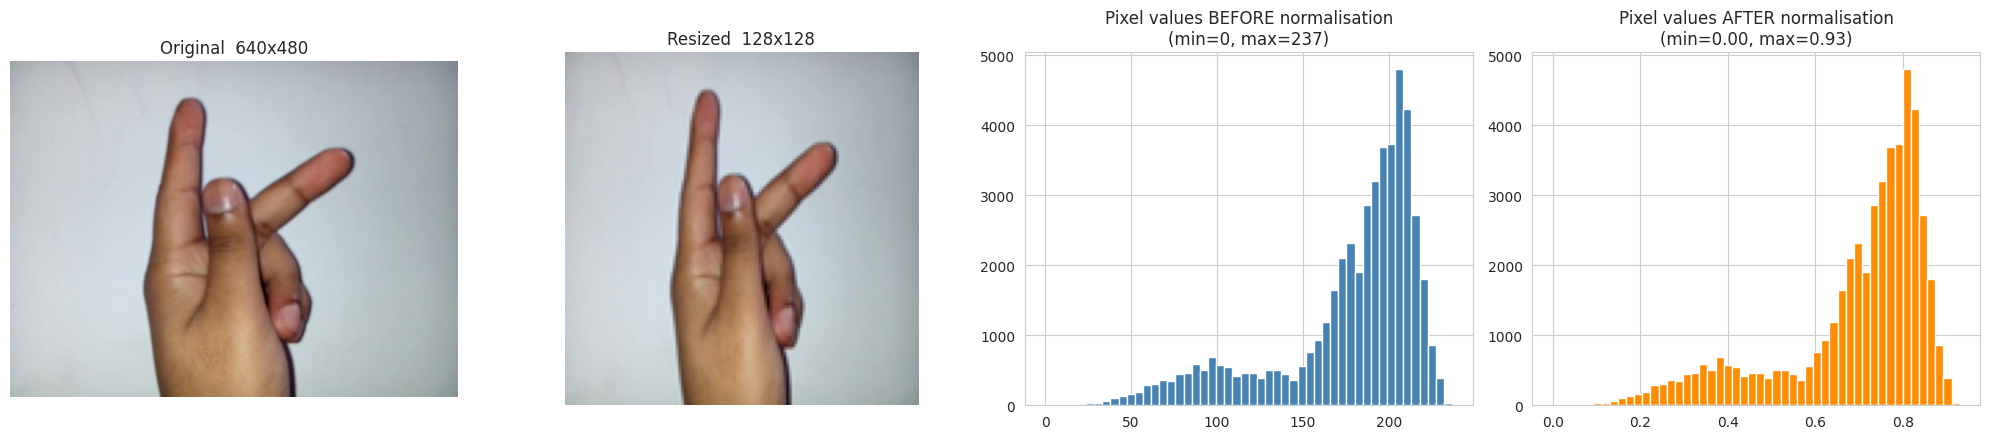

Array shape: (128, 128, 3) | dtype before: uint8 | dtype after: float32


In [14]:
# Visual check of the preprocessing on one image: original -> resized -> pixel-value distribution before/after normalisation
example_path = df.sample(1, random_state=SEED)['path'].values[0]
original = Image.open(example_path)
resized = preprocess_image(example_path)
normalised = resized.astype('float32') / 255.0

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
axes[0].imshow(original);  axes[0].set_title(f'Original  {original.size[0]}x{original.size[1]}');  axes[0].axis('off')
axes[1].imshow(resized);   axes[1].set_title(f'Resized  {IMG_SIZE}x{IMG_SIZE}');                    axes[1].axis('off')
axes[2].hist(resized.ravel(), bins=50, color='steelblue')
axes[2].set_title(f'Pixel values BEFORE normalisation\n(min={resized.min()}, max={resized.max()})')
axes[3].hist(normalised.ravel(), bins=50, color='darkorange')
axes[3].set_title(f'Pixel values AFTER normalisation\n(min={normalised.min():.2f}, max={normalised.max():.2f})')
plt.tight_layout()
plt.show()

print('Array shape:', resized.shape, '| dtype before:', resized.dtype, '| dtype after:', normalised.dtype)

In [15]:
# Preprocess the whole dataset -> X (images) and y (integer labels: 0..NUM_CLASSES-1)
work_df = df.copy()
if MAX_IMAGES_PER_CLASS is not None:
    work_df = work_df.groupby('class').head(MAX_IMAGES_PER_CLASS).reset_index(drop=True)

images, labels, paths = [], [], []
for cls, p in tqdm(zip(work_df['class'], work_df['path']), total=len(work_df), desc='Preprocessing images'):
    images.append(preprocess_image(p))
    labels.append(CLASS_TO_IDX[cls])
    paths.append(p)

X = np.array(images, dtype=np.uint8)
y = np.array(labels)
paths = np.array(paths)
del images
gc.collect()

# Normalise: scale pixel values from 0-255 to 0-1
X = X.astype('float32') / 255.0

print('X shape:', X.shape, '  (images, height, width, channels)')
print('y shape:', y.shape)
print('Pixel value range: {:.1f} to {:.1f}'.format(X.min(), X.max()))
print('Memory used by X: {:.0f} MB'.format(X.nbytes / 1e6))

Preprocessing images:   0%|          | 0/4972 [00:00<?, ?it/s]

X shape: (4972, 128, 128, 3)   (images, height, width, channels)
y shape: (4972,)
Pixel value range: 0.0 to 1.0
Memory used by X: 978 MB


## **7. Train / Validation / Test Split**

The images are divided into three separate sets, each with a different purpose:

**1. Training set (70%)** – the images the CNN learns from.

**2. Validation set (15%)** – used *during development* to monitor training (early stopping) and to choose the best hyperparameters.

**3. Test set (15%)** – kept completely untouched until the very end and used only for the final, unbiased performance estimate on unseen images.

The split is **stratified**, which means every set keeps the same proportion of each sign as the full dataset. This is important here because the classes are moderately imbalanced. **Class weights** are also computed so that mistakes on the smaller classes (such as H, U, V, W) are penalised more heavily during training.

The file paths are split together with the images so that a test image can later be traced back to its original file.

In [16]:
# Stratified 70 / 15 / 15 split (done on indices so that images, labels and file paths always stay aligned)
idx_all = np.arange(len(y))

idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, stratify=y, random_state=SEED)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=SEED)

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]
paths_test = paths[idx_test]

# The full array is no longer needed -> free memory
del X, idx_temp
gc.collect()

print('Training set   :', X_train.shape, y_train.shape)
print('Validation set :', X_val.shape,   y_val.shape)
print('Test set       :', X_test.shape,  y_test.shape)

Training set   : (3480, 128, 128, 3) (3480,)
Validation set : (746, 128, 128, 3) (746,)
Test set       : (746, 128, 128, 3) (746,)


,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
Train,169,181,173,103,170,158,169,81,125,172,...,164,151,148,160,151,95,85,90,141,176
Validation,37,39,37,22,37,34,36,18,27,36,...,35,32,31,35,33,20,18,19,31,37
Test,36,39,37,22,36,34,36,17,27,37,...,35,33,32,34,32,20,19,19,30,38
Total,242,259,247,147,243,226,241,116,179,245,...,234,216,211,229,216,135,122,128,202,251


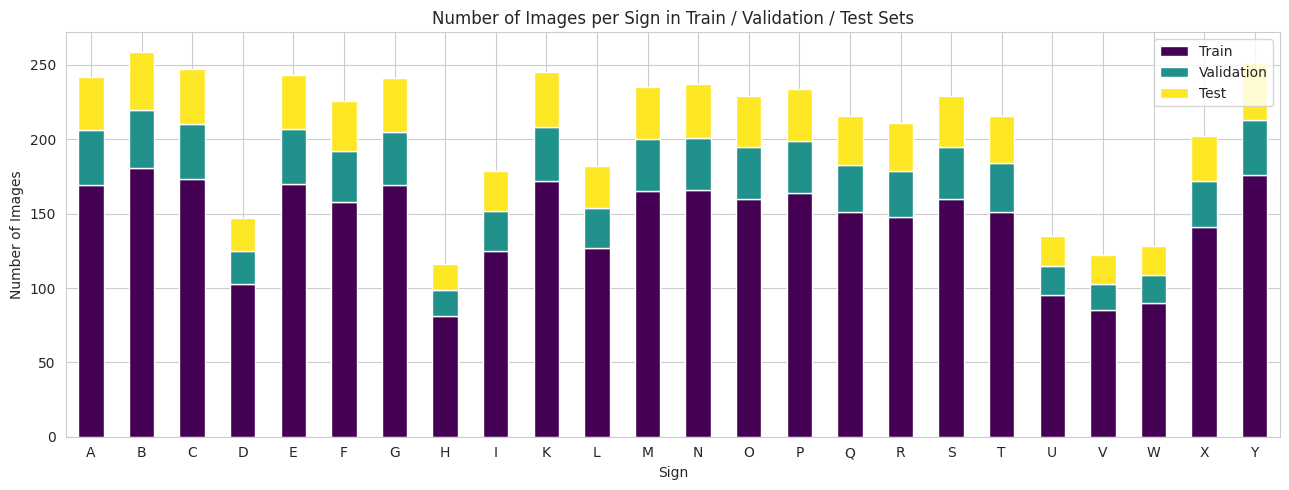

In [17]:
# Check that the class proportions are preserved in every split
split_counts = pd.DataFrame({
    'Train':      pd.Series(y_train).map(dict(enumerate(CLASS_NAMES))).value_counts(),
    'Validation': pd.Series(y_val).map(dict(enumerate(CLASS_NAMES))).value_counts(),
    'Test':       pd.Series(y_test).map(dict(enumerate(CLASS_NAMES))).value_counts()
}).reindex(CLASS_NAMES)
split_counts['Total'] = split_counts.sum(axis=1)

display(split_counts.T)

split_counts[['Train', 'Validation', 'Test']].plot(kind='bar', stacked=True, figsize=(13, 5), colormap='viridis')
plt.title('Number of Images per Sign in Train / Validation / Test Sets')
plt.xlabel('Sign')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Class weights (computed from the TRAINING labels only) to counter the moderate class imbalance
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}

print('Class weights (a value above 1 means the class is under-represented and gets extra importance):')
print({CLASS_NAMES[k]: round(float(v), 2) for k, v in class_weights.items()})

Class weights (a value above 1 means the class is under-represented and gets extra importance):
{'A': 0.86, 'B': 0.8, 'C': 0.84, 'D': 1.41, 'E': 0.85, 'F': 0.92, 'G': 0.86, 'H': 1.79, 'I': 1.16, 'K': 0.84, 'L': 1.14, 'M': 0.88, 'N': 0.87, 'O': 0.91, 'P': 0.88, 'Q': 0.96, 'R': 0.98, 'S': 0.91, 'T': 0.96, 'U': 1.53, 'V': 1.71, 'W': 1.61, 'X': 1.03, 'Y': 0.82}


## **8. Data Augmentation**

With only about 3,500 training images, a CNN can easily **memorise** the training photographs instead of learning the general shape of each sign (overfitting). Data augmentation fights this by showing the network slightly modified versions of the training images at every epoch. The following random changes are used, which mimic real variation in how a person holds their hand in front of a camera:

1. **Rotation** of up to about ±14° (hand tilted).
2. **Translation** (shift) of up to 10% horizontally and vertically (hand not perfectly centred).
3. **Zoom** of up to 10% (hand closer to or further from the camera).

**Horizontal flipping is deliberately NOT used.** A mirrored hand is a left hand turned into a right hand (or vice versa) and may not be a valid, realistic example of the same sign, so flipping could teach the model something that is incorrect.

The augmentation is built from Keras preprocessing layers and placed **at the start of the model**. These layers are active only during training and are automatically switched off during validation, testing and prediction, so the evaluation is always done on the original, unmodified images.

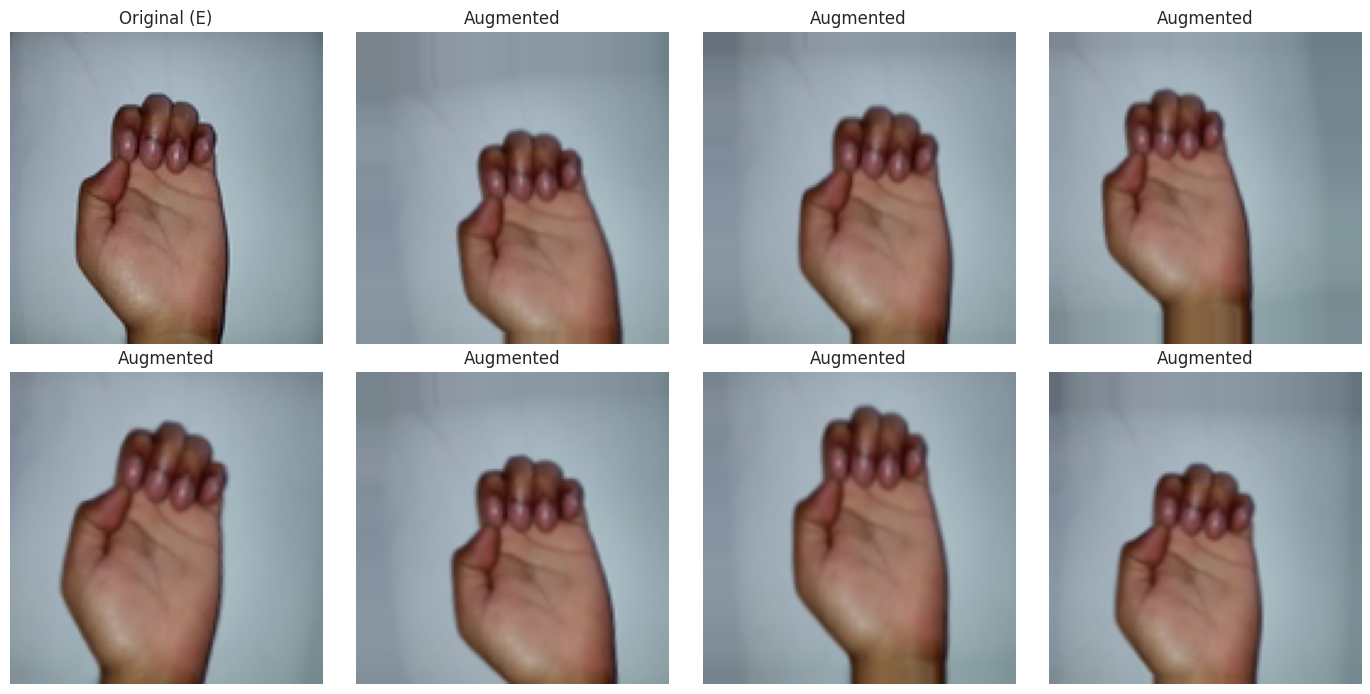

In [19]:
# Augmentation block (active only during training)
data_augmentation = Sequential([
    RandomRotation(factor=0.04, fill_mode='nearest'),                              # +/- ~14 degrees
    RandomTranslation(height_factor=0.10, width_factor=0.10, fill_mode='nearest'), # +/- 10 % shift
    RandomZoom(height_factor=0.10, width_factor=0.10, fill_mode='nearest'),        # +/- 10 % zoom
], name='data_augmentation')

# Visualise: one original training image and 7 random augmented versions of it
sample_img = X_train[0]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title(f'Original ({CLASS_NAMES[y_train[0]]})')
for ax in axes.ravel()[1:]:
    augmented = data_augmentation(np.expand_dims(sample_img, 0), training=True)[0].numpy()
    ax.imshow(np.clip(augmented, 0, 1))
    ax.set_title('Augmented')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

## **9. Model Building & Training — Baseline CNN**

A **baseline** model is built first. It gives a reference score that the tuned model must beat, which shows whether hyperparameter tuning actually helps.

**How the CNN works (layer by layer):**

1. **Convolution layers (`Conv2D`)** – slide small 3×3 filters over the image. The first layer detects simple features such as edges and lines; deeper layers combine them into finger shapes and the overall hand structure.
2. **Max pooling (`MaxPooling2D`)** – shrinks the image while keeping the strongest responses, making the model faster and less sensitive to exact finger position.
3. **Flatten** – converts the extracted 2-D feature maps into a single vector.
4. **Dense layer + Dropout** – combines the features to decide between signs; Dropout randomly switches off some neurons during training to reduce overfitting.
5. **Softmax output layer** – produces one probability for each of the 24 signs. The sign with the highest probability is the prediction.

The model is compiled with the **Adam** optimiser and **sparse categorical cross-entropy** loss (the labels are plain integers 0–23 rather than one-hot vectors). Two callbacks are used: `EarlyStopping` stops training once the validation loss stops improving (and restores the best weights), and `ReduceLROnPlateau` lowers the learning rate when progress stalls.

In [20]:
def build_baseline_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = Sequential([
        Input(shape=input_shape),
        data_augmentation,

        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='baseline_cnn')

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,307,736 (12.62 MB)

 Trainable params: 3,307,736 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Training settings (reduce the epochs for a quicker run)
BASELINE_EPOCHS = 30
BATCH_SIZE      = 32

def get_callbacks(checkpoint_name, patience=5):
    """Fresh callbacks for every training run."""
    return [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        ModelCheckpoint(checkpoint_name, monitor='val_loss', save_best_only=True)
    ]

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=BASELINE_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks('best_baseline_cnn.keras')
)

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.1509 - loss: 2.8959 - val_accuracy: 0.5375 - val_loss: 1.9695 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3862 - loss: 1.9860 - val_accuracy: 0.7440 - val_loss: 0.9903 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.5141 - loss: 1.4869 - val_accuracy: 0.8190 - val_loss: 0.6355 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.5966 - loss: 1.1934 - val_accuracy: 0.8727 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.6440 - loss: 1.0260 - val_accuracy: 0.9008 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.6876 - loss: 0.9061 - val_accuracy: 0.9357 - val_loss: 0.2630 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7247 - loss: 0.

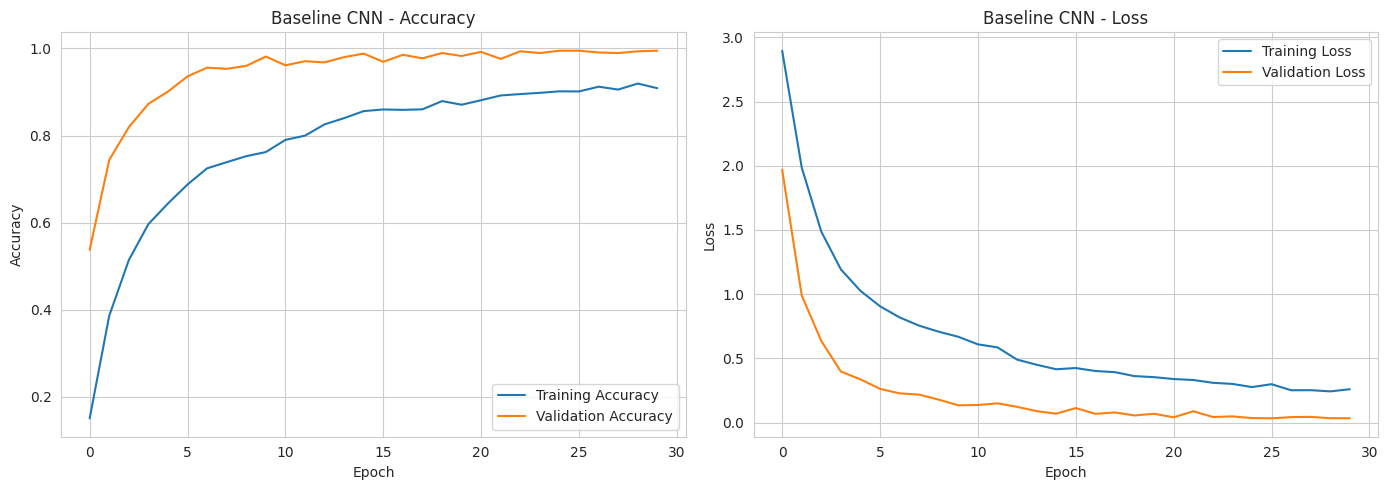

In [22]:
# Helper: accuracy and loss curves. They show learning, convergence and overfitting
# (a growing gap between training and validation curves means overfitting)
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} - Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} - Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline CNN')

In [23]:
# Helper used after every model is trained, so all models are evaluated in exactly the same way
def evaluate_model(model, X_data, y_data):
    y_prob = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_data, y_pred, average='macro', zero_division=0)
    metrics = {
        'Accuracy': accuracy_score(y_data, y_pred),
        'Precision (macro)': precision,
        'Recall (macro)': recall,
        'F1-Score (macro)': f1
    }
    return metrics, y_pred, y_prob

baseline_val_metrics,  _, _ = evaluate_model(baseline_model, X_val, y_val)
baseline_test_metrics, y_pred_baseline, y_prob_baseline = evaluate_model(baseline_model, X_test, y_test)

print('Baseline CNN  - Validation accuracy: {:.4f}'.format(baseline_val_metrics['Accuracy']))
print('Baseline CNN  - Test accuracy      : {:.4f}'.format(baseline_test_metrics['Accuracy']))

Baseline CNN  - Validation accuracy: 0.9946
Baseline CNN  - Test accuracy      : 0.9933


## **10. Hyperparameter Tuning**

**Parameters vs. hyperparameters.** A CNN *learns* its weights and biases automatically during training. But some values must be chosen by us *before* training starts – these are **hyperparameters**. Instead of simply guessing them (for example "learning rate = 0.001"), different combinations are tried and the one that performs best on the **validation set** is selected. The test set is not used for this, so it stays a fair judge of the final model.

**Search space:**

| Hyperparameter | Values tried |
| --- | --- |
| Filters in the 1st convolution layer | 32, 64 |
| Filters in the 2nd convolution layer | 64, 128 |
| Dense layer units | 128, 256 |
| Dropout rate | 0.3, 0.4, 0.5 |
| Learning rate | 0.001, 0.0001 |
| Batch size | 16, 32 |

Trying every combination would be very slow (2 × 2 × 2 × 3 × 2 × 2 = 96 models), so **Keras Tuner's `RandomSearch`** is used: it randomly samples a fixed number of combinations (trials), trains each one briefly, and ranks them by **validation accuracy**. The same augmentation block and class weights are used in every trial, so the tuned model is compared with the baseline fairly.

*Tip:* increase `TUNER_TRIALS` to explore more combinations if time allows.

In [24]:
TUNER_TRIALS = 8      # number of random hyperparameter combinations to try
TUNER_EPOCHS = 15     # maximum epochs per trial (EarlyStopping usually stops earlier)

class ISLHyperModel(kt.HyperModel):
    """CNN whose important hyperparameters are chosen by Keras Tuner."""

    def build(self, hp):
        hp.Choice('batch_size', [16, 32])      # registered here so it is tuned/recorded; it is applied in fit() below
        model = Sequential([Input(shape=INPUT_SHAPE), data_augmentation])

        model.add(Conv2D(hp.Choice('filters_1', [32, 64]), (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))

        model.add(Conv2D(hp.Choice('filters_2', [64, 128]), (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))

        model.add(Conv2D(128, (3, 3), activation='relu'))
        model.add(MaxPooling2D((2, 2)))

        model.add(Flatten())
        model.add(Dense(hp.Choice('dense_units', [128, 256]), activation='relu'))
        model.add(Dropout(hp.Float('dropout', 0.3, 0.5, step=0.1)))
        model.add(Dense(NUM_CLASSES, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [0.001, 0.0001])),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    def fit(self, hp, model, *args, **kwargs):
        # batch size is also treated as a hyperparameter
        return model.fit(*args, batch_size=hp.get('batch_size'), **kwargs)

tuner = kt.RandomSearch(
    ISLHyperModel(),
    objective='val_accuracy',
    max_trials=TUNER_TRIALS,
    seed=SEED,
    overwrite=True,
    directory='isl_tuning',
    project_name='indisignlang'
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
batch_size (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32], 'ordered': True}
filters_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64], 'ordered': True}
filters_2 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
dense_units (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256], 'ordered': True}
dropout (Float)
{'default': 0.3, 'conditions': [], 'min_value': 0.3, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [25]:
# Run the search (each trial trains one randomly chosen combination and reports its validation accuracy)
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=TUNER_EPOCHS,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

Trial 8 Complete [00h 35m 35s]
val_accuracy: 0.9879356622695923

Best val_accuracy So Far: 0.9959785342216492
Total elapsed time: 05h 28m 26s


In [26]:
# Safety check: make sure the trials really finished (Keras Tuner can skip failed trials without stopping)
n_completed = len([t for t in tuner.oracle.trials.values() if t.status == 'COMPLETED'])
print(f'Completed trials: {n_completed} / {TUNER_TRIALS}')
assert n_completed > 0, 'No tuning trial completed - scroll up to read the error message of the failed trials.'

Completed trials: 8 / 8


### **10.1 Tuning Results & Best Hyperparameters**

Every trial is listed below, ranked by validation accuracy. The hyperparameters of the top-ranked trial are the **best hyperparameters**, and these are used to build the final model. They come directly from this notebook's own tuning run on the dataset, not from a pre-decided answer.

In [27]:
# All trials, ranked by validation accuracy
trial_rows = []
for t in tuner.oracle.get_best_trials(num_trials=TUNER_TRIALS):
    row = dict(t.hyperparameters.values)
    row['val_accuracy'] = t.score
    trial_rows.append(row)

tuning_results = pd.DataFrame(trial_rows)
tuning_results.index = np.arange(1, len(tuning_results) + 1)
tuning_results.index.name = 'Rank'
tuning_results.round(4)

,batch_size,filters_1,filters_2,dense_units,dropout,learning_rate,val_accuracy
Rank,,,,,,,
1,32,32,64,256,0.3,0.0010,0.9960
2,32,32,128,128,0.4,0.0010,0.9933
3,16,32,128,256,0.5,0.0010,0.9906
4,16,32,128,128,0.4,0.0010,0.9893
5,16,32,64,256,0.4,0.0001,0.9879
6,32,32,64,128,0.5,0.0010,0.9705
7,16,32,128,128,0.4,0.0001,0.9638
8,32,32,64,128,0.5,0.0001,0.8968


In [28]:
# Best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print('BEST HYPERPARAMETERS (selected on validation accuracy)')
print('-' * 55)
print('Filters (conv layer 1) :', best_hp.get('filters_1'))
print('Filters (conv layer 2) :', best_hp.get('filters_2'))
print('Dense layer units      :', best_hp.get('dense_units'))
print('Dropout rate           :', best_hp.get('dropout'))
print('Learning rate          :', best_hp.get('learning_rate'))
print('Batch size             :', best_hp.get('batch_size'))

BEST HYPERPARAMETERS (selected on validation accuracy)
-------------------------------------------------------
Filters (conv layer 1) : 32
Filters (conv layer 2) : 64
Dense layer units      : 256
Dropout rate           : 0.3
Learning rate          : 0.001
Batch size             : 32


## **11. Final CNN Model**

The tuner only trained each candidate for a short time. The final model is therefore built with the **best hyperparameters** and trained again from scratch for longer on the training set, still monitoring the validation set with `EarlyStopping` and `ReduceLROnPlateau`. Its accuracy and loss curves are plotted to check learning, convergence and overfitting.

In [29]:
FINAL_EPOCHS     = 40
FINAL_BATCH_SIZE = best_hp.get('batch_size')

final_model = tuner.hypermodel.build(best_hp)
final_model.summary()

history_final = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=FINAL_BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks('best_final_cnn.keras', patience=6)
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,522,200 (24.88 MB)

 Trainable params: 6,522,200 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.2500 - loss: 2.5049 - val_accuracy: 0.6475 - val_loss: 1.1948 - learning_rate: 0.0010
Epoch 2/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.5853 - loss: 1.2673 - val_accuracy: 0.8968 - val_loss: 0.4560 - learning_rate: 0.0010
Epoch 3/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7365 - loss: 0.7986 - val_accuracy: 0.9102 - val_loss: 0.2842 - learning_rate: 0.0010
Epoch 4/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8023 - loss: 0.6188 - val_accuracy: 0.9437 - val_loss: 0.1797 - learning_rate: 0.0010
Epoch 5/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8397 - loss: 0.5006 - val_accuracy: 0.9397 - val_loss: 0.1823 - learning_rate: 0.0010
Epoch 6/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8739 - loss: 0.4036 - val_accuracy: 0.9732 - val_loss: 0.0949 - learning_rate: 0.0010
Epoch 7/40
109/109 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8782 - loss: 0.

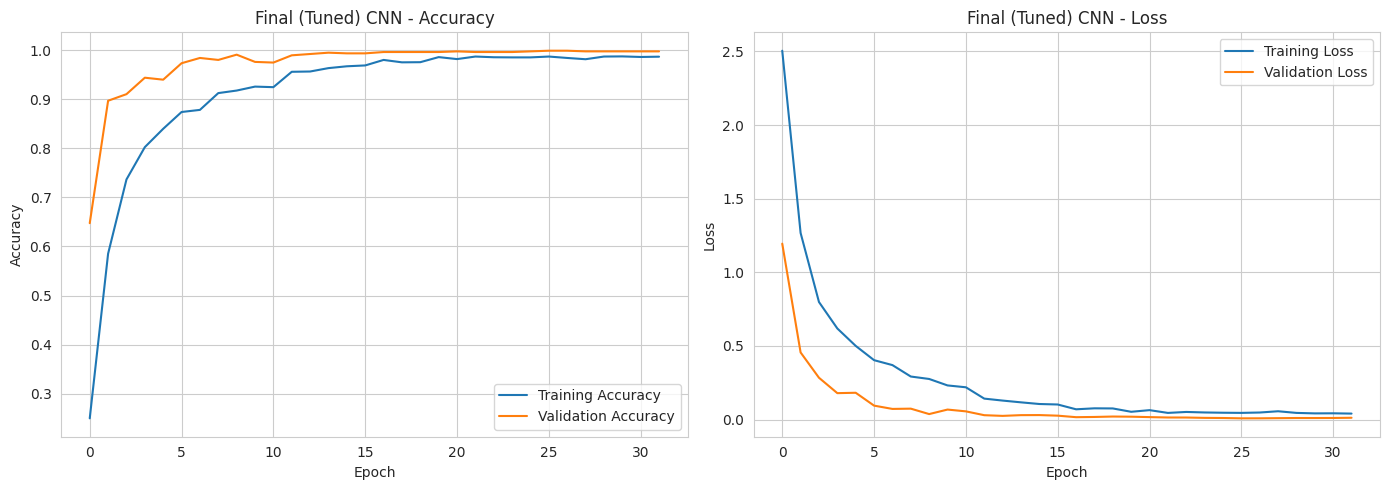

In [30]:
plot_history(history_final, 'Final (Tuned) CNN')

In [31]:
final_val_metrics,  _, _ = evaluate_model(final_model, X_val, y_val)
final_test_metrics, y_pred_final, y_prob_final = evaluate_model(final_model, X_test, y_test)

print('Final CNN  - Validation accuracy: {:.4f}'.format(final_val_metrics['Accuracy']))
print('Final CNN  - Test accuracy      : {:.4f}'.format(final_test_metrics['Accuracy']))

Final CNN  - Validation accuracy: 0.9987
Final CNN  - Test accuracy      : 1.0000


## **12. Model Comparison Report**

The baseline CNN and the tuned final CNN are compared on both the validation and the test set using Accuracy and the macro-averaged Precision, Recall and F1-score. *Macro* averaging gives every sign equal importance regardless of how many images it has, which suits this moderately imbalanced dataset.

The best model is **selected using the validation accuracy** (not the test accuracy), so the test set is never used to make a modelling decision. The test scores then give an honest estimate of how the selected model performs on unseen images.

In [32]:
comparison = pd.DataFrame({
    'Baseline CNN - Validation': baseline_val_metrics,
    'Baseline CNN - Test':       baseline_test_metrics,
    'Final Tuned CNN - Validation': final_val_metrics,
    'Final Tuned CNN - Test':       final_test_metrics
}).T
comparison.round(4)

,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Baseline CNN - Validation,0.9946,0.9944,0.9932,0.9937
Baseline CNN - Test,0.9933,0.9936,0.9921,0.9926
Final Tuned CNN - Validation,0.9987,0.9980,0.9978,0.9979
Final Tuned CNN - Test,1.0000,1.0000,1.0000,1.0000


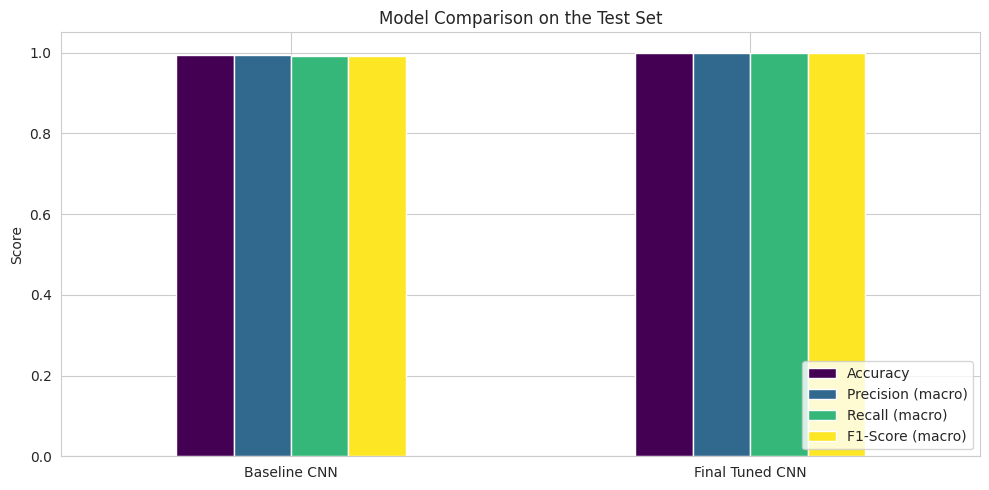

In [33]:
# Visual comparison on the test set
test_comparison = comparison.loc[['Baseline CNN - Test', 'Final Tuned CNN - Test']]
test_comparison.index = ['Baseline CNN', 'Final Tuned CNN']

test_comparison.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Model Comparison on the Test Set')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

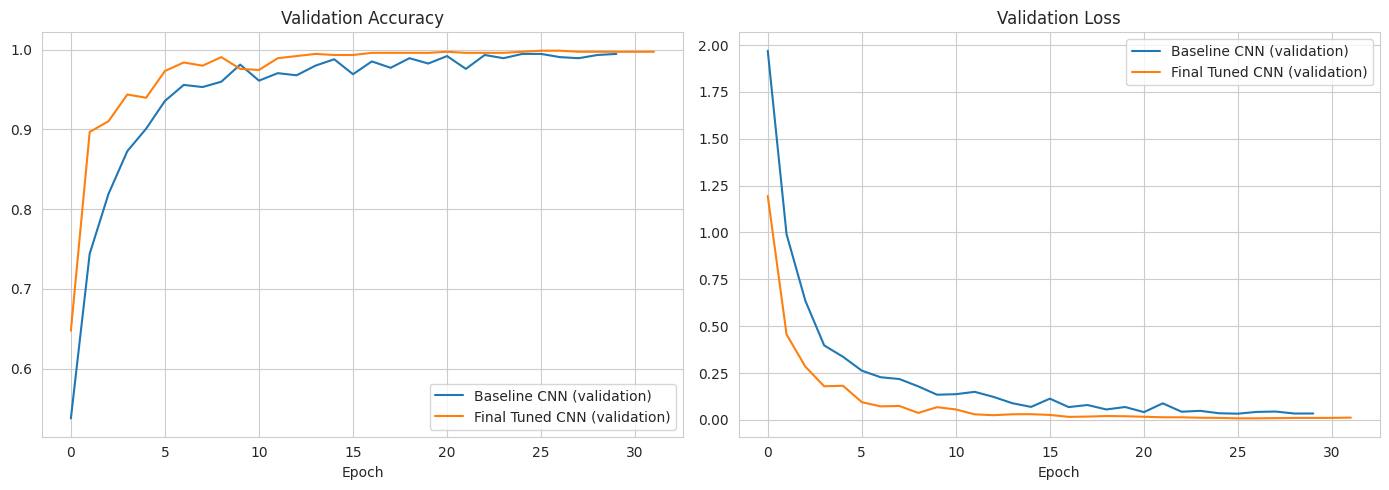

In [34]:
# Training curves of both models together
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in {'Baseline CNN': history_baseline, 'Final Tuned CNN': history_final}.items():
    axes[0].plot(h.history['val_accuracy'], label=f'{name} (validation)')
    axes[1].plot(h.history['val_loss'], label=f'{name} (validation)')
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].set_title('Validation Loss');     axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

In [35]:
# Select the best model using VALIDATION accuracy
candidates = {
    'Baseline CNN':    (baseline_model, baseline_val_metrics, y_pred_baseline, y_prob_baseline),
    'Final Tuned CNN': (final_model,    final_val_metrics,    y_pred_final,    y_prob_final)
}
best_model_name = max(candidates, key=lambda k: candidates[k][1]['Accuracy'])
best_model, _, y_pred_best, y_prob_best = candidates[best_model_name]

print('Best model (highest validation accuracy):', best_model_name)
print('Its test accuracy: {:.4f}'.format(accuracy_score(y_test, y_pred_best)))

Best model (highest validation accuracy): Final Tuned CNN
Its test accuracy: 1.0000


## **13. Best Model — Detailed Evaluation**

The selected model is evaluated in more depth on the **unseen test set**:

1. **Classification Report** – for each sign: *Precision* (of the images predicted as this sign, how many really were it?), *Recall* (of all real images of this sign, how many were found?), *F1-score* (the balance of the two) and *Support* (the number of test images).
2. **Confusion Matrix** – rows are the actual signs and columns are the predicted signs. Correct predictions lie on the diagonal; any value off the diagonal shows which signs are being confused with each other.
3. **Per-sign F1-score and most confused pairs** – to see exactly which signs the model finds easy or hard.
4. **Misclassified images** – to look at the actual mistakes.

In [36]:
# Full classification report
print(f'Classification Report - {best_model_name} (Test Set)')
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES, zero_division=0))

Classification Report - Final Tuned CNN (Test Set)
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        36
           B       1.00      1.00      1.00        39
           C       1.00      1.00      1.00        37
           D       1.00      1.00      1.00        22
           E       1.00      1.00      1.00        36
           F       1.00      1.00      1.00        34
           G       1.00      1.00      1.00        36
           H       1.00      1.00      1.00        17
           I       1.00      1.00      1.00        27
           K       1.00      1.00      1.00        37
           L       1.00      1.00      1.00        28
           M       1.00      1.00      1.00        35
           N       1.00      1.00      1.00        36
           O       1.00      1.00      1.00        34
           P       1.00      1.00      1.00        35
           Q       1.00      1.00      1.00        33
           R       1.00      1

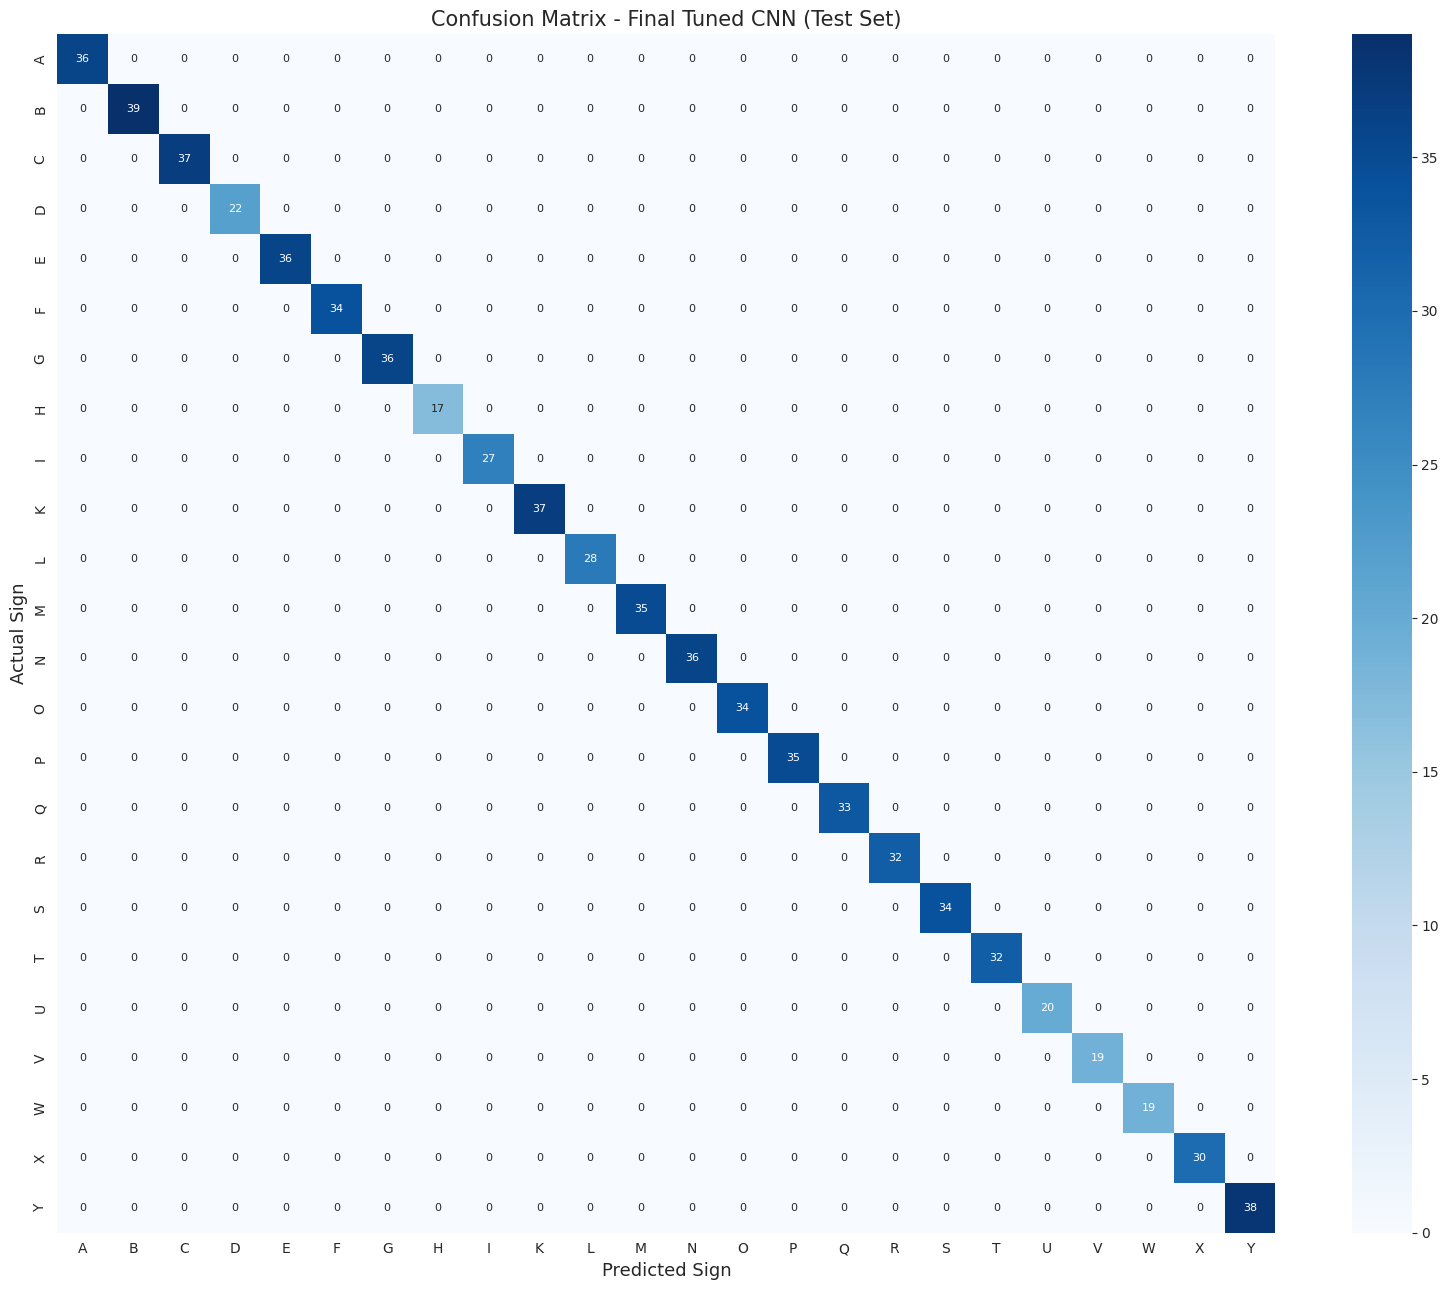

In [37]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, annot_kws={'size': 8})
plt.xlabel('Predicted Sign', fontsize=13)
plt.ylabel('Actual Sign', fontsize=13)
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)', fontsize=15)
plt.tight_layout()
plt.show()

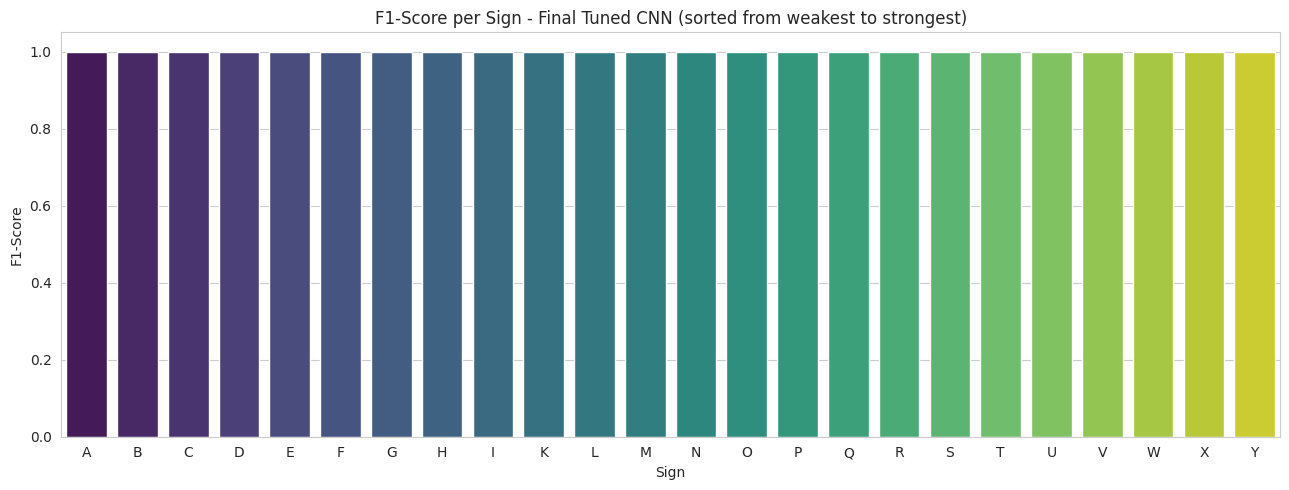

5 weakest signs  : A (1.00), B (1.00), C (1.00), D (1.00), E (1.00)
5 strongest signs: U (1.00), V (1.00), W (1.00), X (1.00), Y (1.00)


In [38]:
# Per-sign F1-score (which signs are easy / hard for the model?)
_, _, f1_per_class, support = precision_recall_fscore_support(y_test, y_pred_best, zero_division=0)
f1_series = pd.Series(f1_per_class, index=CLASS_NAMES).sort_values()

plt.figure(figsize=(13, 5))
sns.barplot(x=f1_series.index, y=f1_series.values, palette='viridis')
plt.title(f'F1-Score per Sign - {best_model_name} (sorted from weakest to strongest)')
plt.xlabel('Sign')
plt.ylabel('F1-Score')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('5 weakest signs  :', ', '.join(f'{c} ({v:.2f})' for c, v in f1_series.head(5).items()))
print('5 strongest signs:', ', '.join(f'{c} ({v:.2f})' for c, v in f1_series.tail(5).items()))

In [39]:
# Most frequently confused pairs of signs (largest off-diagonal values of the confusion matrix)
confused = []
for actual in range(NUM_CLASSES):
    for predicted in range(NUM_CLASSES):
        if actual != predicted and cm[actual, predicted] > 0:
            confused.append({'Actual sign': CLASS_NAMES[actual],
                             'Predicted as': CLASS_NAMES[predicted],
                             'Number of images': cm[actual, predicted]})

if confused:
    confused_df = pd.DataFrame(confused).sort_values('Number of images', ascending=False).head(10).reset_index(drop=True)
    display(confused_df)
else:
    print('No misclassified test images - the confusion matrix is perfectly diagonal.')

No misclassified test images - the confusion matrix is perfectly diagonal.


In [40]:
# Look at some of the actual mistakes (original, un-resized photographs)
wrong_idx = np.where(y_pred_best != y_test)[0]
print(f'Misclassified test images: {len(wrong_idx)} out of {len(y_test)}')

if len(wrong_idx) > 0:
    show_idx = wrong_idx[:12]
    n_cols = 4
    n_rows = int(np.ceil(len(show_idx) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, i in zip(axes, show_idx):
        ax.imshow(Image.open(paths_test[i]))
        conf = y_prob_best[i, y_pred_best[i]] * 100
        ax.set_title(f'Actual: {CLASS_NAMES[y_test[i]]}  |  Predicted: {CLASS_NAMES[y_pred_best[i]]}\n(confidence {conf:.0f}%)',
                     color='red', fontsize=11)
        ax.axis('off')
    for ax in axes[len(show_idx):]:
        ax.axis('off')
    plt.suptitle('Misclassified Test Images', fontsize=15)
    plt.tight_layout()
    plt.show()

Misclassified test images: 0 out of 746


## **14. Predicting the Sign of a New Image**

This section shows the complete application working end to end:

**New hand image → Resize → Normalise → CNN → Probability for each sign → Highest probability → Predicted ISL sign**

The `predict_sign()` function reuses the *same* `preprocess_image()` function that was used for training, so a new image is treated exactly like the training images. It returns the predicted sign together with the model's **confidence** (the softmax probability) and the top-3 most likely signs. Note that confidence is the model's own estimate; it is **not a guarantee** that the prediction is correct.

In [41]:
def predict_sign(image_path, model=None, top_k=3, show=True):
    """Predict the sign shown in ONE image file. Returns (predicted_sign, confidence, top_k list)."""
    model = model if model is not None else best_model
    array = preprocess_image(image_path).astype('float32') / 255.0          # resize + normalise (same as training)
    probs = model.predict(np.expand_dims(array, axis=0), verbose=0)[0]      # add batch dimension -> probabilities
    top_idx = np.argsort(probs)[::-1][:top_k]
    top = [(CLASS_NAMES[i], float(probs[i])) for i in top_idx]

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].imshow(Image.open(image_path))
        axes[0].set_title(f'Predicted Sign: {top[0][0]}  ({top[0][1]*100:.1f}%)', fontsize=13)
        axes[0].axis('off')
        axes[1].barh([t[0] for t in top][::-1], [t[1] * 100 for t in top][::-1], color='steelblue')
        axes[1].set_xlim(0, 100); axes[1].set_xlabel('Confidence (%)'); axes[1].set_title(f'Top-{top_k} predictions')
        plt.tight_layout()
        plt.show()
    return top[0][0], top[0][1], top

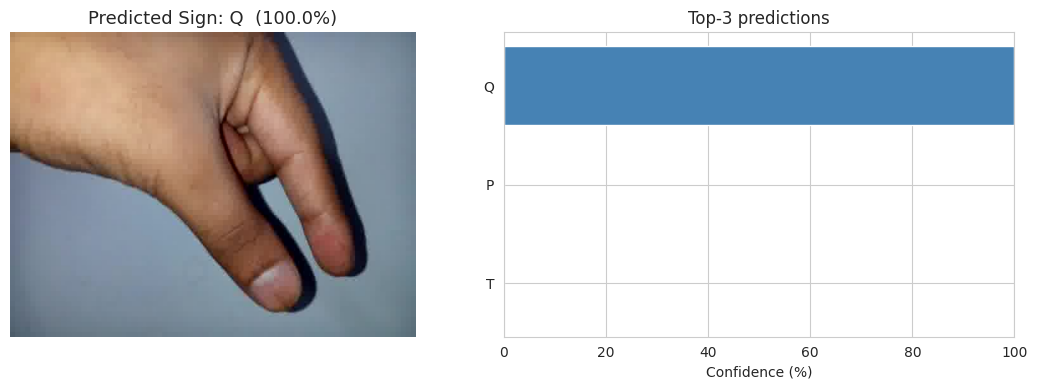

Actual sign: Q  |  Predicted sign: Q  |  Confidence: 100.0%  |   CORRECT
--------------------------------------------------------------------------------


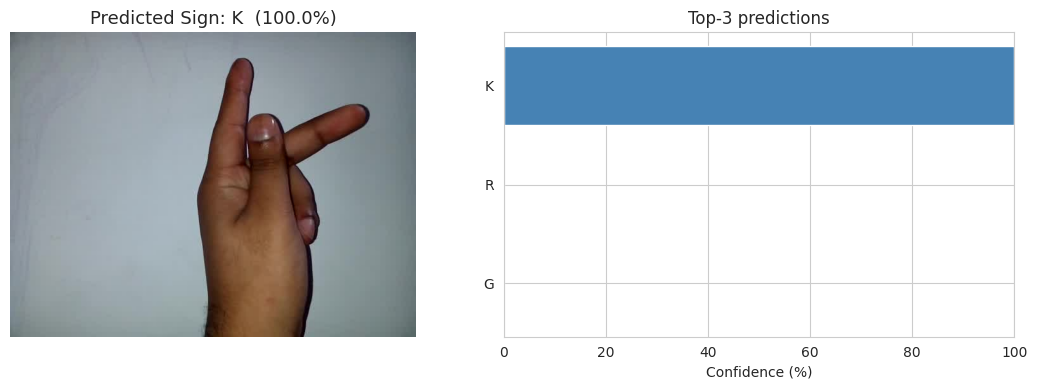

Actual sign: K  |  Predicted sign: K  |  Confidence: 100.0%  |   CORRECT
--------------------------------------------------------------------------------


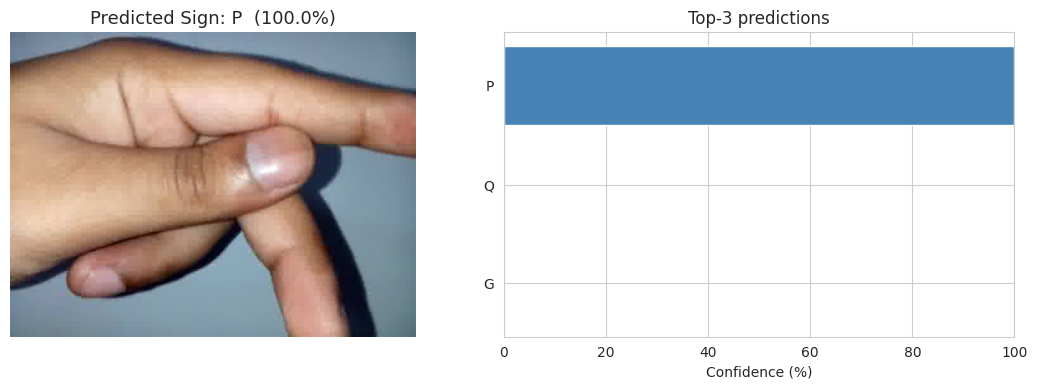

Actual sign: P  |  Predicted sign: P  |  Confidence: 100.0%  |   CORRECT
--------------------------------------------------------------------------------


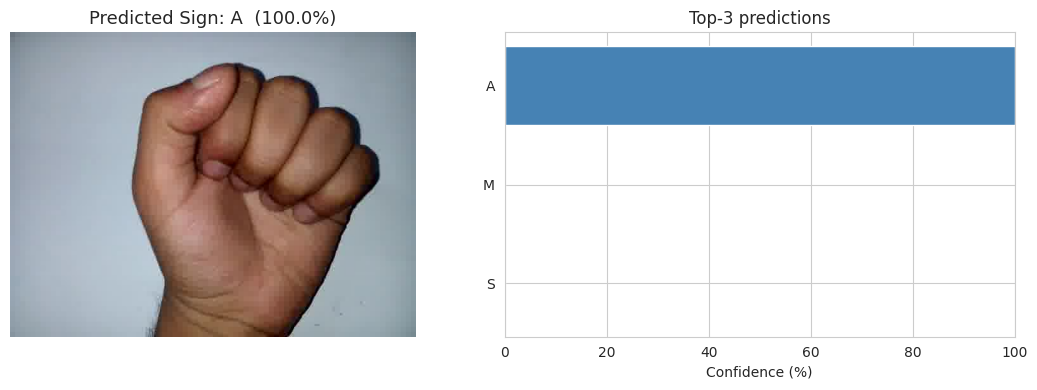

Actual sign: A  |  Predicted sign: A  |  Confidence: 100.0%  |   CORRECT
--------------------------------------------------------------------------------


In [42]:
# Demonstration on 4 random images from the unseen test set
random.seed(SEED)
for i in random.sample(range(len(paths_test)), 4):
    sign, conf, _ = predict_sign(paths_test[i])
    print(f'Actual sign: {CLASS_NAMES[y_test[i]]}  |  Predicted sign: {sign}  |  Confidence: {conf*100:.1f}%  |  ',
          'CORRECT' if sign == CLASS_NAMES[y_test[i]] else 'WRONG')
    print('-' * 80)

In [43]:
# OPTIONAL: predict on your OWN image
# Option 1 (any environment): put the path of your image here, e.g. MY_IMAGE_PATH = 'my_sign.jpg'
MY_IMAGE_PATH = None
# Option 2 (Google Colab only): set to True to get an upload button
UPLOAD_OWN_IMAGE = False

if MY_IMAGE_PATH:
    predict_sign(MY_IMAGE_PATH)

if UPLOAD_OWN_IMAGE:
    try:
        from google.colab import files
        for fname in files.upload():
            predict_sign(fname)
    except ImportError:
        print('Upload is only available in Google Colab. Use MY_IMAGE_PATH instead.')

## **15. Save the Model**

The selected model is saved in the native Keras format (`.keras`) together with the class-name list, so that it can be loaded later (for example in a web app or mobile app) without retraining. The saved model is then re-loaded and its predictions are compared with the original model to confirm that it was saved correctly.

In [44]:
MODEL_PATH = 'IndiSignLang_CNN_Model.keras'
best_model.save(MODEL_PATH)

with open('IndiSignLang_class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

# Verify: reload and compare predictions on 20 test images
reloaded_model = tf.keras.models.load_model(MODEL_PATH)
same = np.allclose(best_model.predict(X_test[:20], verbose=0),
                   reloaded_model.predict(X_test[:20], verbose=0), atol=1e-5)

print(f'Model saved as         : {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)')
print('Class names saved as   : IndiSignLang_class_names.json')
print('Reloaded model gives identical predictions:', same)

Model saved as         : IndiSignLang_CNN_Model.keras  (78.3 MB)
Class names saved as   : IndiSignLang_class_names.json
Reloaded model gives identical predictions: True


In [45]:
# Final results summary (values are generated from THIS run, nothing is hard-coded)
final_acc = accuracy_score(y_test, y_pred_best)
final_prec, final_rec, final_f1, _ = precision_recall_fscore_support(y_test, y_pred_best, average='macro', zero_division=0)

print('=' * 60)
print('   PRAICP-1000 : INDIAN SIGN LANGUAGE RECOGNITION - RESULTS')
print('=' * 60)
print(f'Number of sign classes       : {NUM_CLASSES}')
print(f'Images (train / val / test)  : {len(y_train)} / {len(y_val)} / {len(y_test)}')
print(f'Input size                   : {IMG_SIZE} x {IMG_SIZE} x 3')
print(f'Selected model               : {best_model_name}')
print(f'Test accuracy                : {final_acc*100:.2f} %')
print(f'Test precision (macro)       : {final_prec:.4f}')
print(f'Test recall (macro)          : {final_rec:.4f}')
print(f'Test F1-score (macro)        : {final_f1:.4f}')
print('=' * 60)

   PRAICP-1000 : INDIAN SIGN LANGUAGE RECOGNITION - RESULTS
Number of sign classes       : 24
Images (train / val / test)  : 3480 / 746 / 746
Input size                   : 128 x 128 x 3
Selected model               : Final Tuned CNN
Test accuracy                : 100.00 %
Test precision (macro)       : 1.0000
Test recall (macro)          : 1.0000
Test F1-score (macro)        : 1.0000


## **16. Business Insights**

**1. Assistive Communication Tool:**<br>
The trained CNN turns a photograph of a hand sign into a predicted letter within a fraction of a second. Integrated into a phone or web application, such a model can act as a communication aid that helps people who do not know sign language to understand sign-language users, improving accessibility in schools, hospitals, banks and public offices.<br><br>

**2. Preprocessing Makes Real-World Use Possible:**<br>
The raw photographs came in three different resolutions and orientations. Resizing and normalising every image (and applying exactly the same steps to new images at prediction time) is what allows one model to handle photos from different cameras consistently.<br><br>

**3. Confusion Analysis Shows Where to Improve:**<br>
The confusion matrix, the per-sign F1-scores and the misclassified-image gallery (Section 13) show which signs are confused with one another. These signs are the best targets for collecting more varied training photographs, so that improvement effort can be focused instead of spread across the whole dataset.<br><br>

**4. Hyperparameter Tuning Adds Measurable Value:**<br>
The tuned model is compared against the untuned baseline on the same validation and test data (Section 12). Because the comparison is reported openly, the benefit of tuning can be judged from evidence instead of assumption.<br><br>

**5. Scope and Deployment Considerations:**<br>
The model recognises **static letter signs** from a single image. Real conversation also needs words, sentences, two-handed signs and motion. The model is a first building block; a production system would extend it with video/sequence models and be validated with sign-language users before real-world use.

## **17. Challenges Faced**

**1. Images of Different Sizes and Orientations:**<br>
The dataset contains 640×480 landscape photographs, 1920×1088 landscape photographs and 1088×1920 portrait photographs. All were converted to a common 128×128 RGB format. A fast JPEG "draft" decode is used while loading so that the large images do not slow down preprocessing.<br><br>

**2. Moderate Class Imbalance:**<br>
Some signs (such as B and Y) have more than twice as many images as others (such as H, U, V and W). This was handled with stratified train/validation/test splitting and with class weights during training, and the models are judged with macro-averaged metrics so that small classes count equally.<br><br>

**3. Visually Similar Signs:**<br>
Certain signs differ only by small changes in finger or thumb position. A small CNN can confuse them, so the confusion matrix and classification report are examined sign by sign instead of relying only on overall accuracy.<br><br>

**4. Risk of Overfitting on a Relatively Small Dataset:**<br>
With around 3,500 training images, the network can memorise the training photographs. Data augmentation (rotation, shift, zoom), dropout, early stopping and learning-rate reduction were all used to reduce overfitting. Horizontal flipping was deliberately avoided, because a mirrored hand may not be a valid example of the same sign.<br><br>

**5. Avoiding Information Leakage in Model Selection:**<br>
To keep the final score honest, hyperparameters and the best model were selected using only the validation set. The test set was used only once at the end for the final evaluation.<br><br>

**6. Memory and Compute Limits:**<br>
Loading nearly 5,000 images into memory and searching many hyperparameter combinations can be heavy. Images are stored at 128×128, the full-size arrays are deleted after splitting, and the number of tuner trials and epochs are configurable (`TUNER_TRIALS`, `TUNER_EPOCHS`, `MAX_IMAGES_PER_CLASS`) so the notebook can be run on modest hardware.

## **18. Final Conclusion**

**1.Project Objective:**

The objective of this project was to build a machine learning model that recognises Indian Sign Language signs from images, covering the two goals of the DataMites brief: image preprocessing and an ML model to predict the sign.
<br><br>

**2.Exploratory Data Analysis (EDA):**

EDA showed a 24-class dataset of single-hand photographs on plain backgrounds, moderate class imbalance (about 2.2 : 1), three different original resolutions, and natural variation between images of the same sign – which justified resizing, normalisation, stratified splitting, class weights and data augmentation.
<br><br>

**3.Modelling:**

A baseline CNN was built first, then Keras Tuner's random search was used to select the number of filters, dense units, dropout rate, learning rate and batch size using validation accuracy. A final CNN was trained with the best hyperparameters, and both models were compared using the same metrics.
<br><br>

**4.Outcome:**

The selected model's accuracy, macro precision/recall/F1-score, classification report and confusion matrix on the unseen test set are reported in Sections 12–13 and in the final results summary in Section 15. The model can predict the sign of a new image with its confidence (Section 14) and has been saved for later use. Its remaining errors are concentrated in visually similar signs, and future work can include more varied training photographs, transfer learning with pretrained networks, two-handed and motion-based signs, and real-time webcam recognition.

# **19. Project Links**

The following links provide access to the complete project resources, including the source code, dataset, and supporting documentation. Replace the placeholders below with your own repository / drive links before submission.

## **1. GitHub Repository**
Access the complete source code, Jupyter Notebook, README, and project files.

🔗 **GitHub Repository:**  https://github.com/Sameekshagithub/PRAICP-1000-Indian-Sign-Language-ISL-Recognition-Using-CNN.git

---

## **2. Google Drive**
Access the PPT and REPORT.

🔗 **Google Drive:** https://drive.google.com/drive/folders/1uiFsyNDpfCWIWidHgfDLZDjr36PixxGG?usp=drive_link